In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy
import math
from scipy.optimize import curve_fit
import statsmodels.api as sm
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from sklearn import tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import csv

import loess
from loess import loess_1d
import json

In [2]:
#Convenient datastructure to keep our algorithms straight
algosdict = {}
algosdict[0] = 'support vector machine'
algosdict[1] = 'random forest'
algosdict[2] = 'k nearest neighbors'
algosdict[3] = 'multilayer perceptron'
algosdict[4] = 'stochastic gradient descent'
algosdict[5] = 'decision tree'
algosdict[6] = 'linear discriminant analysis'
algosdict[7] = 'quadratic discriminany analysis'
algosdict[8] = 'gaussian process classifier'
algosdict[9] = 'multinomial naive bayes'
algosdict[10] = 'gradient boosting classifier'
algosdict[11] = 'logistic regression'

In [3]:
#This is where the data is read, and the train/test split is performed
df = pd.read_csv("C:/Users/pieth/Desktop/Work/Dad/DAMSEL/mousedrinkingdatafixed.csv")
y = df[['Label']]
X = df.drop(columns=['Label'])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, test_size=.66)

In [4]:
#Here the data is sequentially truncated and models are fitted to them
#A full list of the algorithms and parameters used is included in the appendix
X_vals = list(range(1,53))
Y_vals = [[],[],[],[],[],[],[],[],[],[],[],[]]
for i in range(1,53):
    X_adjusted = X.iloc[:,0:i]
    Y_adjusted = y.iloc[:,0:i]
    X_train, X_test, y_train, y_test = train_test_split(X_adjusted, Y_adjusted, random_state=1, test_size=.66)
    
    clf = SVC(kernel='linear', C=1).fit(X_train, y_train.values.ravel())
    Y_vals[0].append(clf.score(X_test, y_test))
    clf = RandomForestClassifier().fit(X_train, y_train.values.ravel())
    Y_vals[1].append(clf.score(X_test, y_test))
    clf = KNeighborsClassifier(3).fit(X_train, y_train.values.ravel())
    Y_vals[2].append(clf.score(X_test, y_test))
    clf = MLPClassifier(random_state=1, max_iter=300).fit(X_train, y_train.values.ravel())
    Y_vals[3].append(clf.score(X_test, y_test))
    clf = SGDClassifier(loss='hinge').fit(X_train, y_train.values.ravel())
    Y_vals[4].append(clf.score(X_test, y_test))
    clf = tree.DecisionTreeClassifier().fit(X_train, y_train.values.ravel())
    Y_vals[5].append(clf.score(X_test, y_test))
    clf = LinearDiscriminantAnalysis().fit(X_train, y_train.values.ravel())
    Y_vals[6].append(clf.score(X_test, y_test))
    clf = QuadraticDiscriminantAnalysis().fit(X_train, y_train.values.ravel())
    Y_vals[7].append(clf.score(X_test, y_test))
    clf = GaussianProcessClassifier().fit(X_train, y_train.values.ravel())
    Y_vals[8].append(clf.score(X_test, y_test))
    clf = MultinomialNB().fit(X_train, y_train.values.ravel())
    Y_vals[9].append(clf.score(X_test, y_test))
    clf = GradientBoostingClassifier().fit(X_train, y_train.values.ravel())
    Y_vals[10].append(clf.score(X_test, y_test))
    clf = LogisticRegression().fit(X_train, y_train.values.ravel())
    Y_vals[11].append(clf.score(X_test, y_test))

C:\Users\pieth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pieth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pieth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\pieth\A

In [5]:
#Alternatively, if you wish to use the fixed data from paper, it can be loaded from the files in the github
#Please fill in the paths to the appropriate locations the repository is saved to in your filesystem
with open("C:/Users/pieth/Desktop/Work/Dad/DAMSEL/fixed yvals.json", "r") as file:
    Y_vals = json.load(file)
X_vals = list(range(1,53))

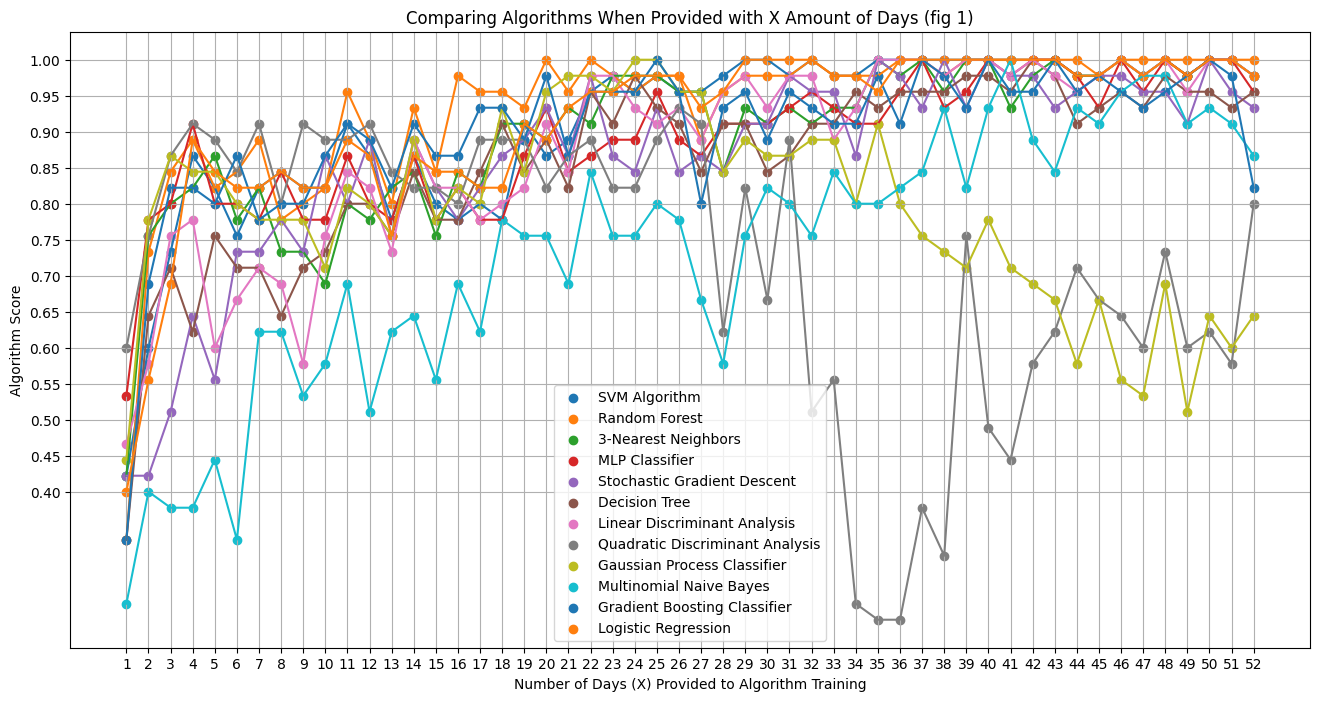

In [6]:
#Here the data from before is plotted to generate a figure
#This is the code to generate the raw data for Fig 3
fig = plt.figure(figsize=(16, 8))
salplot = plt.subplot(1,1,1)

for i in range(len(Y_vals)):
    plt.plot(X_vals, Y_vals[i])

plt.scatter(X_vals, Y_vals[0], label="SVM Algorithm")
plt.scatter(X_vals, Y_vals[1], label="Random Forest")
plt.scatter(X_vals, Y_vals[2], label="3-Nearest Neighbors")
plt.scatter(X_vals, Y_vals[3], label="MLP Classifier")
plt.scatter(X_vals, Y_vals[4], label="Stochastic Gradient Descent")
plt.scatter(X_vals, Y_vals[5], label="Decision Tree")
plt.scatter(X_vals, Y_vals[6], label="Linear Discriminant Analysis")
plt.scatter(X_vals, Y_vals[7], label="Quadratic Discriminant Analysis")
plt.scatter(X_vals, Y_vals[8], label="Gaussian Process Classifier")
plt.scatter(X_vals, Y_vals[9], label="Multinomial Naive Bayes")
plt.scatter(X_vals, Y_vals[10], label="Gradient Boosting Classifier")
plt.scatter(X_vals, Y_vals[11], label="Logistic Regression")
plt.title('Comparing Algorithms When Provided with X Amount of Days (fig 1)')
plt.ylabel('Algorithm Score')
plt.xlabel('Number of Days (X) Provided to Algorithm Training')
plt.xticks(range(1,53))
plt.yticks(np.arange(.40, 1.05, 0.05))


plt.grid()
plt.legend()

plt.show()

In [7]:
#Here is the section where loess and means are fitted to the data to extract summary statistics
#All parameters that are not default are specified here
def loess_process(df):
    data = df.drop(columns=['Label'])
    x = range(len(data.columns))
    y = data.mean()
    return loess_1d.loess_1d(np.array(x), np.array(y))

def mean_process(df):
    data = df.drop(columns=['Label'])
    x = range(len(data.columns))
    y = data.mean(axis=0)
    return np.array(x), np.array(y)

def fit_rawdata(data):
    sorted_data = data.sort_values(by=['Label'])
    aframe = sorted_data[sorted_data['Label'] =='A']
    bframe = sorted_data[sorted_data['Label'] =='B']
    cframe = sorted_data[sorted_data['Label'] =='C']

    ax, ay, _ = loess_process(aframe)
    bx, by, _ = loess_process(bframe)
    cx, cy, _ = loess_process(cframe)

    fig = plt.figure(figsize=(16, 8))
    salplot = plt.subplot(1,1,1)
    #plt.plot(X_vals, Y_vals[n])
    plt.plot(ax, ay.tolist())
    plt.plot(bx, by.tolist())
    plt.plot(cx, cy.tolist())
    #plt.scatter(X_vals, Y_vals[n])
    plt.title('Loess fit on simulated group data') #title this
    plt.ylabel('Algorithm Score')
    plt.xlabel('Number of Days (X) Provided to Algorithm Training')
    plt.xticks(range(1,53))
    plt.yticks(np.arange(0, 10, 1))
    plt.axis((0,55,0,10))
    plt.grid()
    plt.legend()
    plt.show()

C:\Users\pieth\AppData\Local\Temp\ipykernel_11056\1117278502.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


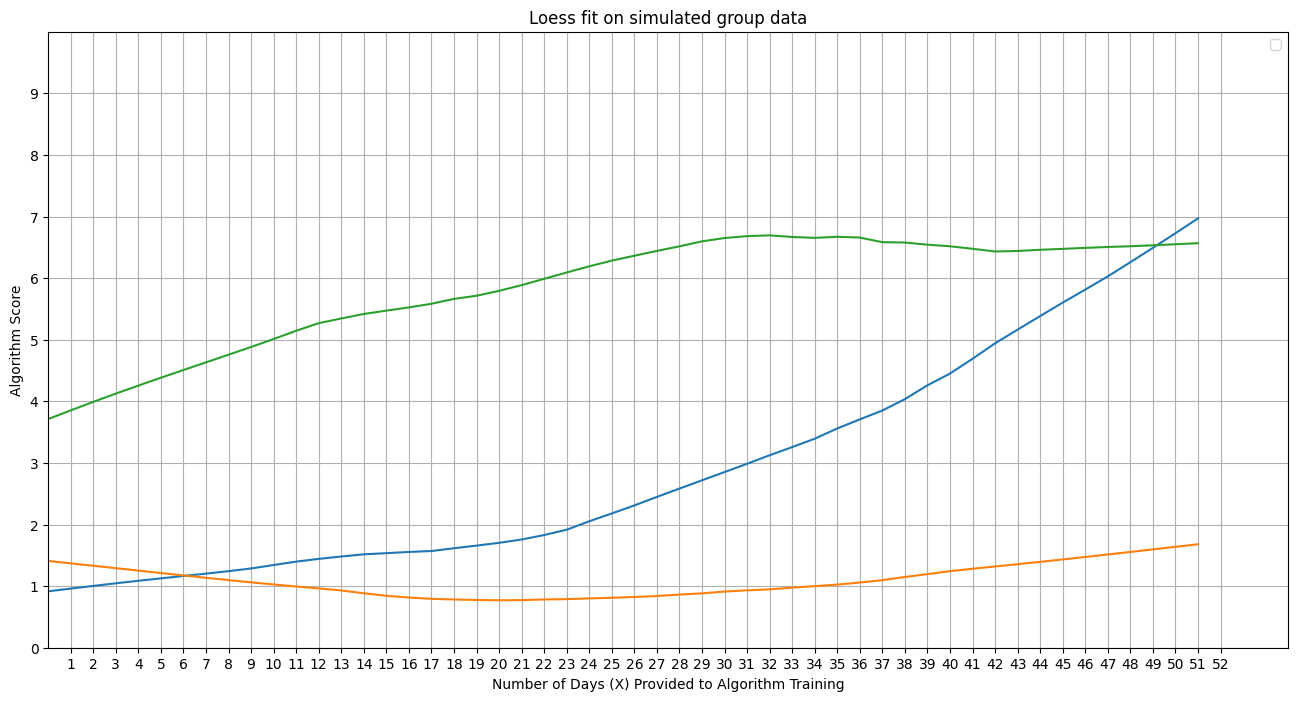

In [8]:
fit_rawdata(df)

In [9]:
#Code for loess fits, relating to Figures 4, 5, and Table 1

def find_loess_intercept(algo, intercept, bounds):
    #remember indexes are 0 indexed, days are 1 indexed
    newlo, newhi = bounds
    newlo, newhi = newlo - 1, newhi - 1

    xout, yout, wtout = loess_1d.loess_1d(np.array(X_vals), np.array(Y_vals[algo]))

    downshift = []
    for n in range(len(Y_vals[algo])):
        downshift.append(yout[n] - intercept)

    downshift = np.array(downshift)
    sign = np.sign(downshift)
    signchange = ((np.roll(sign, 1) - sign) != 0).astype(int) #first element is always positive, skip it
    #print(downshift)
    #print(signchange)

    for i in range(1, len(signchange)):
        if signchange[i] == 1: return i+1
    #if this doesnt occur the there was no sign change, so every value must be either all above 0 or below 0
    if(downshift[0]) >= 0: return 1
    else: return 52

def convert_tuples(L):
    res = []
    for i in range(len(L)):
        assert(len(L[i]) == 2)
        res.append((L[i][0], L[i][1]))
    return res

def split_list(L):
    resx = []
    resy = []
    for i in range(len(L)):
        assert(len(L[i]) == 2)
        resx.append(L[i][0])
        resy.append(L[i][1])
    return resx, resy

In [10]:
#Code to generate figure 4
#frac refers to the frac parameters as described in the loess documentation
def plot_all_loess(frac = 0.5):
    for n in range(len(Y_vals)):
        #xout, yout, wout = loess_1d.loess_1d(np.array(X_vals), np.array(Y_vals[n]), frac=frac)
        #plot_algo(n, X_vals, Y_vals, yout.tolist(), "loess")
        lowess = sm.nonparametric.lowess
        res = lowess(Y_vals[n], X_vals, frac=frac)
        yout = []
        for i in range(len(res)):
            yout.append(res[i][1])
        print(yout)

        fig = plt.figure(figsize=(16, 8))
        salplot = plt.subplot(1,1,1)
        plt.plot(X_vals, Y_vals[n])
        plt.plot(X_vals, yout)
        plt.scatter(X_vals, Y_vals[n])
        plt.title(f'Loess fit on algorithm {algosdict[n]}')
        plt.ylabel('Algorithm Score')
        plt.xlabel('Number of Days (X) Provided to Algorithm Training')
        plt.xticks(range(1,53))
        plt.yticks(np.arange(0, 1.2, 0.05))
        plt.axis((0,55,0,1.2))
        plt.grid()
        plt.legend()
        plt.show()

[np.float64(0.5589849391290151), np.float64(0.5999651630276154), np.float64(0.6409421534821786), np.float64(0.6818630980556484), np.float64(0.7228872538818084), np.float64(0.7657507660116318), np.float64(0.7991721344766439), np.float64(0.8137996753838881), np.float64(0.8251033923670218), np.float64(0.8300424756812231), np.float64(0.8298678702133558), np.float64(0.8253272592252922), np.float64(0.8210506620284225), np.float64(0.8171939851041122), np.float64(0.8080966015196066), np.float64(0.8039459120673208), np.float64(0.8138359307243049), np.float64(0.82895064279451), np.float64(0.84910003287673), np.float64(0.8740283471782059), np.float64(0.8999035390272492), np.float64(0.9231358659256109), np.float64(0.9401214614205017), np.float64(0.9532179258064435), np.float64(0.9627087234673163), np.float64(0.9681486652574232), np.float64(0.9730696280476214), np.float64(0.9776862992709566), np.float64(0.9820838024723584), np.float64(0.9860660850618421), np.float64(0.9882805673652524), np.float64(

C:\Users\pieth\AppData\Local\Temp\ipykernel_11056\1398221029.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


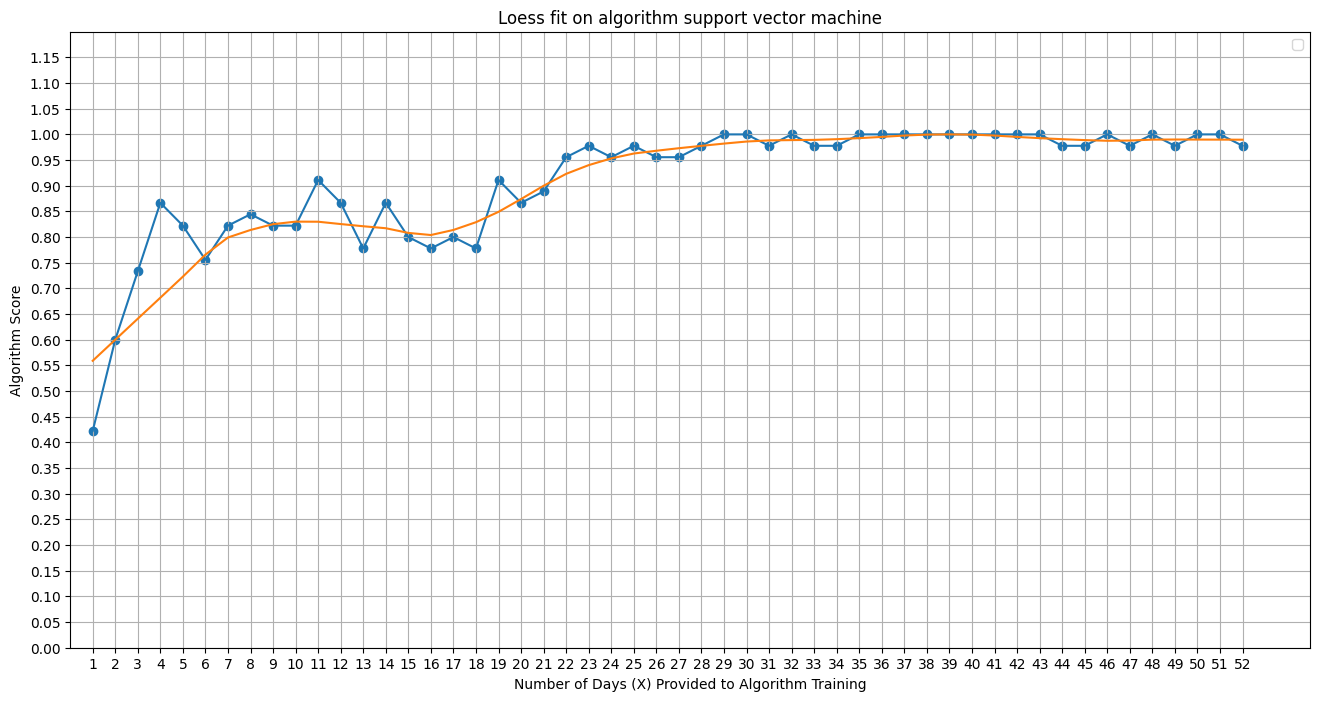

[np.float64(0.8482126297031284), np.float64(0.8444820082791368), np.float64(0.8411234003485115), np.float64(0.8381794976162088), np.float64(0.8352646998530916), np.float64(0.8305457453141187), np.float64(0.8271119317116352), np.float64(0.8294276792876117), np.float64(0.8367204444677818), np.float64(0.8388863206056638), np.float64(0.8547236411067489), np.float64(0.8820160592323838), np.float64(0.9055736914695195), np.float64(0.9236663634821471), np.float64(0.9373127712114646), np.float64(0.9476397555040449), np.float64(0.9542308900159382), np.float64(0.9579294969066317), np.float64(0.9612164027803717), np.float64(0.9643140681792407), np.float64(0.9668300877214735), np.float64(0.9699638054846029), np.float64(0.9728600572181457), np.float64(0.9735403363424149), np.float64(0.9722958082171822), np.float64(0.9713727583592274), np.float64(0.9719727611713107), np.float64(0.9736051336152284), np.float64(0.9748719003490361), np.float64(0.9765819694601154), np.float64(0.9791247435775773), np.floa

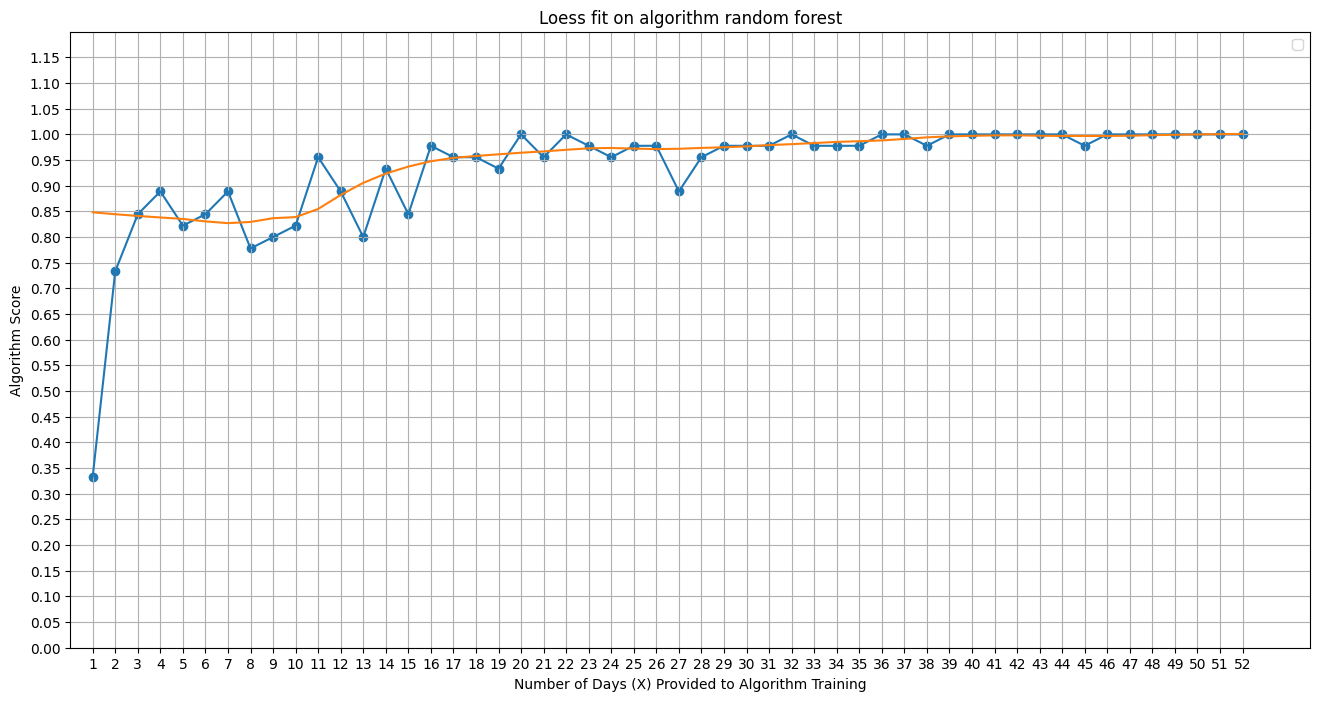

[np.float64(0.7864748342507842), np.float64(0.7926234270757618), np.float64(0.7965268649572824), np.float64(0.7985228041575928), np.float64(0.799343622115399), np.float64(0.7911242066550963), np.float64(0.7792327024643433), np.float64(0.7714047335634706), np.float64(0.7686283674660802), np.float64(0.7710926146213914), np.float64(0.7786050634827848), np.float64(0.7925207061620683), np.float64(0.8065890257824354), np.float64(0.8180534785511261), np.float64(0.8317194262463343), np.float64(0.8468660130850675), np.float64(0.8602325772114571), np.float64(0.8745369823801755), np.float64(0.8915952387672562), np.float64(0.9092041578624085), np.float64(0.9256621796687855), np.float64(0.938769816372025), np.float64(0.948989007520106), np.float64(0.9574248984369105), np.float64(0.9610641340480149), np.float64(0.9574935410648734), np.float64(0.9494301849427152), np.float64(0.9409563015417658), np.float64(0.9332735583877552), np.float64(0.9276608973063187), np.float64(0.9258213126350859), np.float64

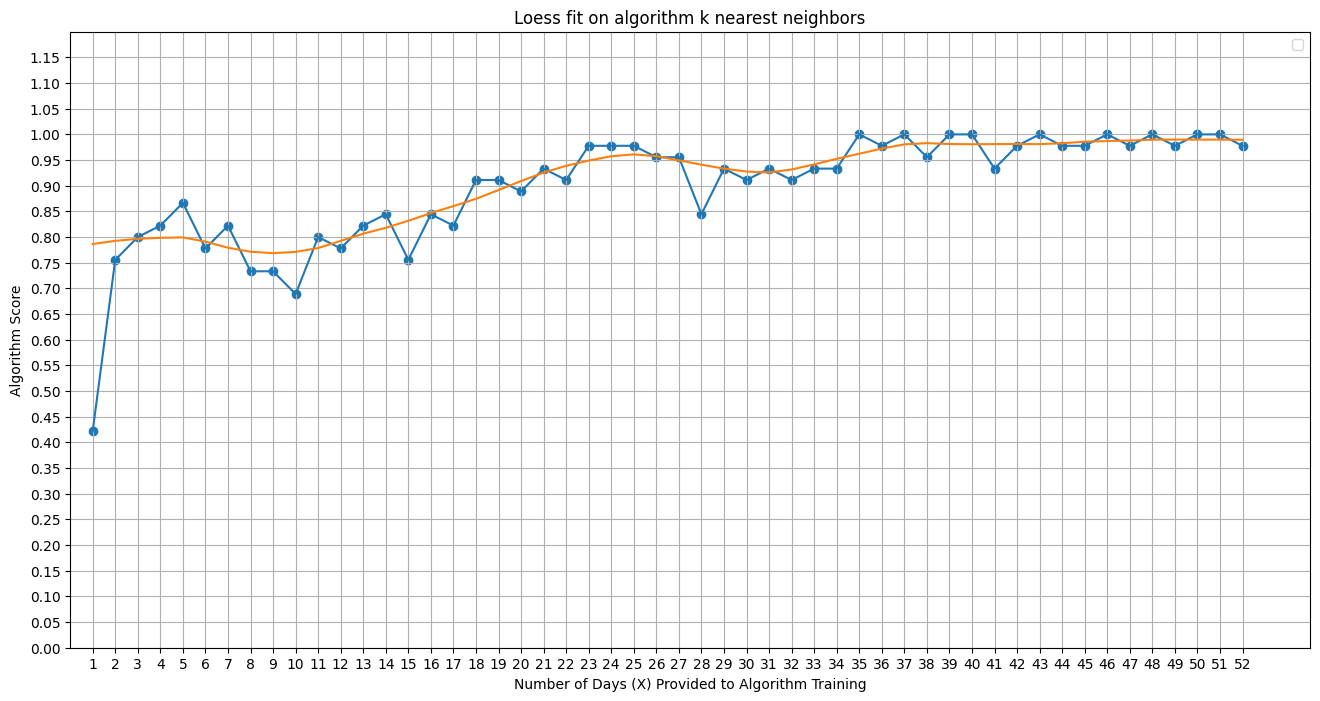

[np.float64(0.7834993649442237), np.float64(0.7869058279712995), np.float64(0.7900241947291827), np.float64(0.7931543522147354), np.float64(0.796536347638479), np.float64(0.7983509273496755), np.float64(0.7979772298530536), np.float64(0.7988331737379238), np.float64(0.8006959537979095), np.float64(0.801541415419662), np.float64(0.8027894681581672), np.float64(0.803678400589649), np.float64(0.8055066196322468), np.float64(0.8044363252620146), np.float64(0.8019617924269183), np.float64(0.8052178766830924), np.float64(0.8136177417312699), np.float64(0.8231145534778501), np.float64(0.8334338148632883), np.float64(0.8460586678141958), np.float64(0.8617540598246994), np.float64(0.8756317863477605), np.float64(0.8831813859090847), np.float64(0.8876779001318962), np.float64(0.8926946046450475), np.float64(0.8977459578642345), np.float64(0.9013471265977022), np.float64(0.9047349347282683), np.float64(0.9108038923721488), np.float64(0.9189851864235526), np.float64(0.9246239520936346), np.float64

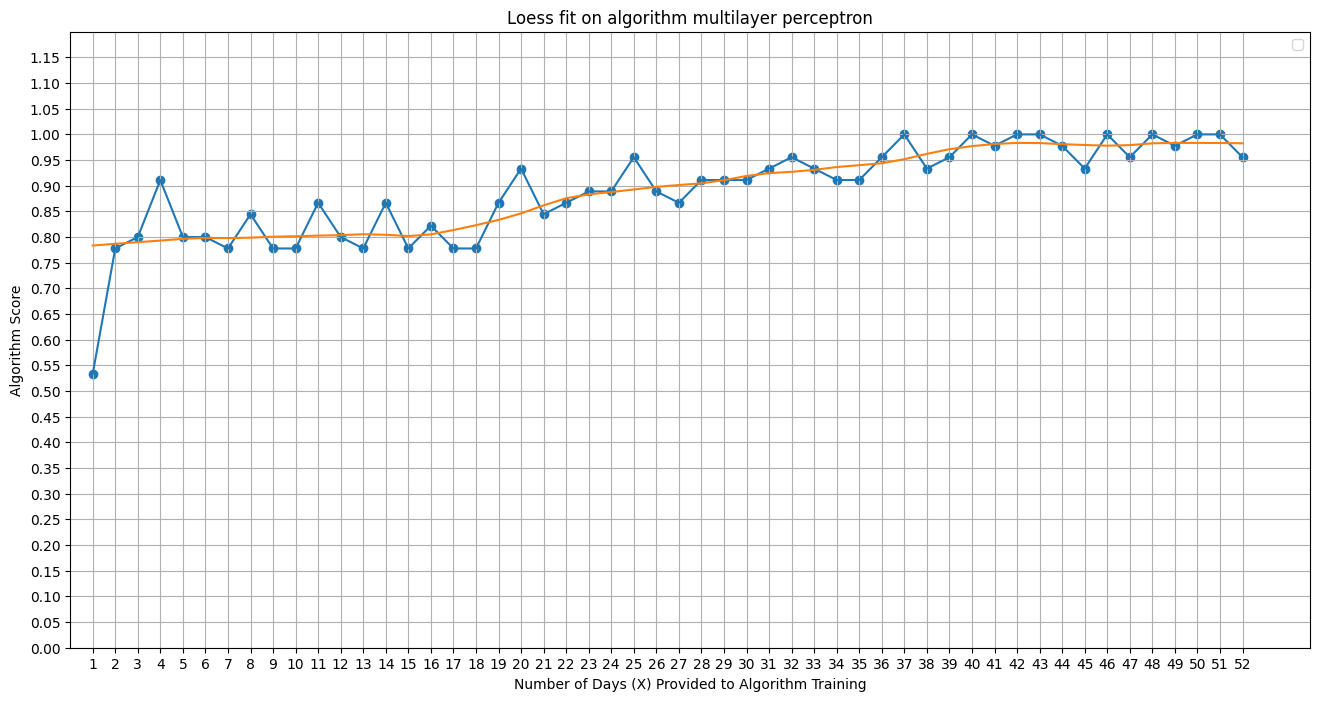

[np.float64(0.40436417304095623), np.float64(0.4603603301618387), np.float64(0.5157485327977882), np.float64(0.5705634364213491), np.float64(0.6259356714347737), np.float64(0.6746786250276742), np.float64(0.7172881906770567), np.float64(0.7521357039840435), np.float64(0.780808352201307), np.float64(0.7987964625265941), np.float64(0.8130305811055104), np.float64(0.8229525853716739), np.float64(0.8267726840594113), np.float64(0.8255680980635501), np.float64(0.827504364588722), np.float64(0.8339712235275013), np.float64(0.8457775222478827), np.float64(0.8585744076484388), np.float64(0.8746895180377482), np.float64(0.886448408698865), np.float64(0.8906759937618981), np.float64(0.8908803255910903), np.float64(0.8870293350975623), np.float64(0.8803236557787018), np.float64(0.8740353043424842), np.float64(0.8722691218553604), np.float64(0.8777089921226505), np.float64(0.8884312453177438), np.float64(0.9020566141745291), np.float64(0.9179655812680451), np.float64(0.932003647237656), np.float64

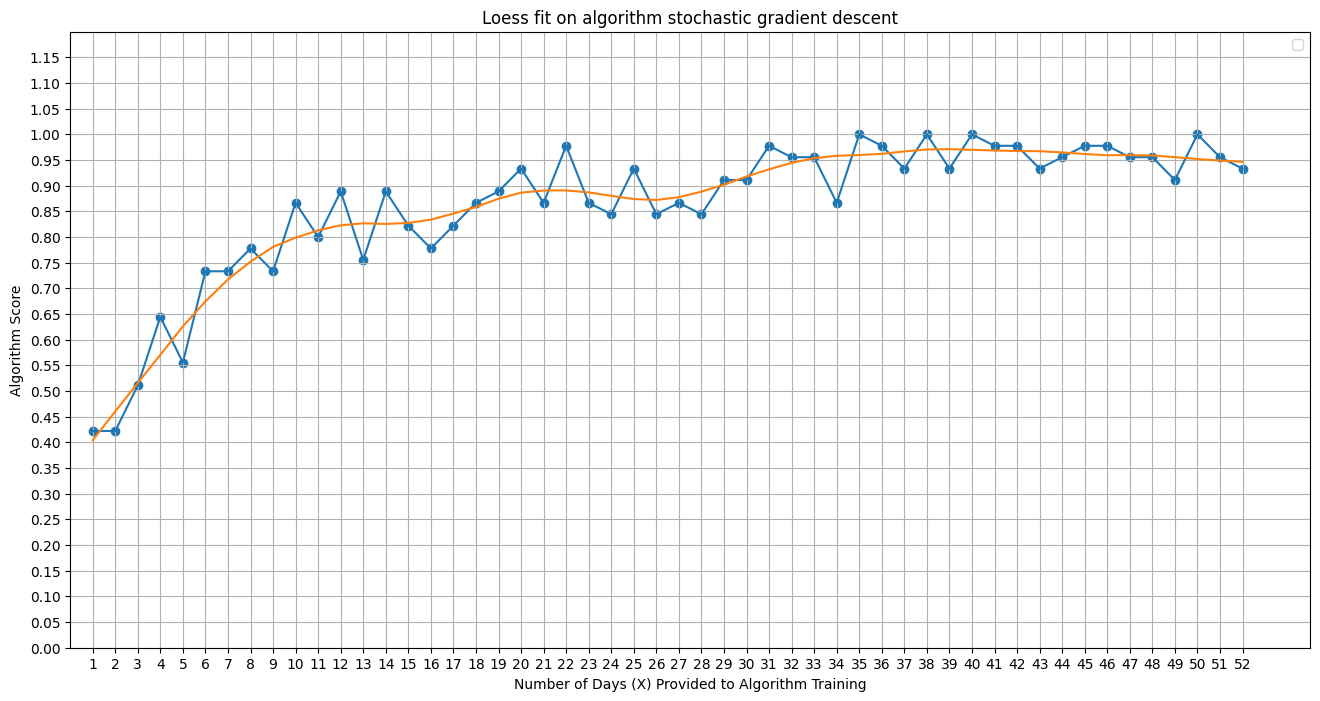

[np.float64(0.6447294013636894), np.float64(0.6568183674325448), np.float64(0.6684535423931187), np.float64(0.6796614323778485), np.float64(0.6897946201754108), np.float64(0.6967619587606189), np.float64(0.7052616001741006), np.float64(0.7176204910559059), np.float64(0.7306236723741564), np.float64(0.7437689706534696), np.float64(0.7598988346541551), np.float64(0.7752498339353249), np.float64(0.7861436232281424), np.float64(0.795912901885149), np.float64(0.8067132781513197), np.float64(0.8190479460590868), np.float64(0.83243671169532), np.float64(0.8470026122864892), np.float64(0.8655804434507869), np.float64(0.8831549742487282), np.float64(0.8978953087685838), np.float64(0.9095998874248501), np.float64(0.9190227941419492), np.float64(0.9232486774294855), np.float64(0.9208751019886351), np.float64(0.9150630133211606), np.float64(0.9061167299280806), np.float64(0.8956004127972432), np.float64(0.8904041599200477), np.float64(0.89174565085832), np.float64(0.8976534336164586), np.float64(0

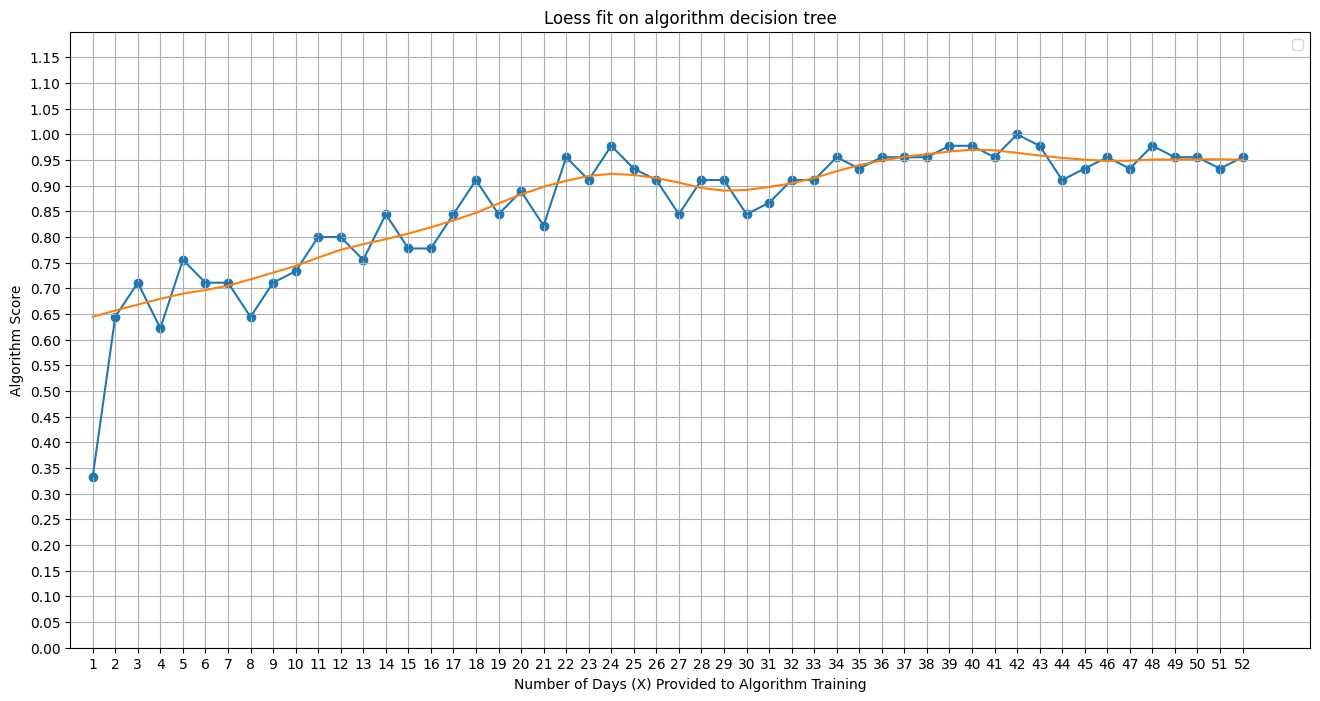

[np.float64(0.5015340650456157), np.float64(0.5328324822066688), np.float64(0.5645706291982933), np.float64(0.5970180342118113), np.float64(0.6296833215401172), np.float64(0.6547510936935987), np.float64(0.6817821079002082), np.float64(0.7131283700883934), np.float64(0.7418896563541157), np.float64(0.7649663404848992), np.float64(0.7860069458615869), np.float64(0.804605185873434), np.float64(0.8148147003931282), np.float64(0.8170727209303298), np.float64(0.8153794285753135), np.float64(0.8156329195700641), np.float64(0.8205649355607509), np.float64(0.8286906352200123), np.float64(0.8454145602099756), np.float64(0.8697865616817007), np.float64(0.893373783765013), np.float64(0.9111202253491754), np.float64(0.9235834206622084), np.float64(0.9301597656464521), np.float64(0.9331958425496683), np.float64(0.9335099473456387), np.float64(0.9354538852938671), np.float64(0.9412019920901027), np.float64(0.9490214798403894), np.float64(0.9541117653575545), np.float64(0.9552952916352428), np.float6

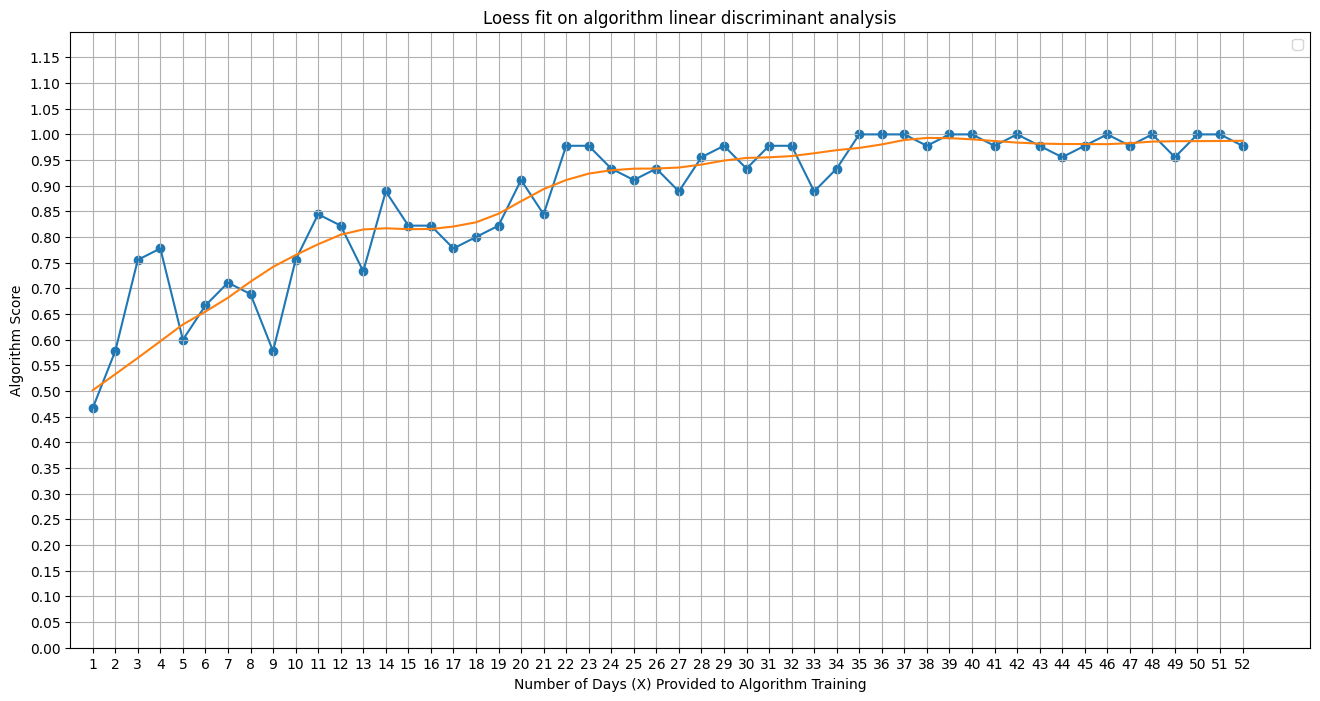

[np.float64(0.7207352772927786), np.float64(0.75980517833888), np.float64(0.7953918187981075), np.float64(0.8291985037559784), np.float64(0.8616244661931647), np.float64(0.8734289589327765), np.float64(0.8762213144638311), np.float64(0.877398693903102), np.float64(0.8799079916278463), np.float64(0.8805904454463512), np.float64(0.8766105636996542), np.float64(0.8686426776819126), np.float64(0.8570438643996459), np.float64(0.8490477955291664), np.float64(0.8467868062323858), np.float64(0.8485623062309282), np.float64(0.8524050707186593), np.float64(0.858522541754347), np.float64(0.8648529527249563), np.float64(0.8653321158256632), np.float64(0.8591892235662709), np.float64(0.8561764315928866), np.float64(0.8614220010745804), np.float64(0.869213644967603), np.float64(0.8691795161141801), np.float64(0.8570700168448583), np.float64(0.8356988278376811), np.float64(0.799821646730335), np.float64(0.7444194283068116), np.float64(0.6814075159405358), np.float64(0.6089089458903327), np.float64(0.

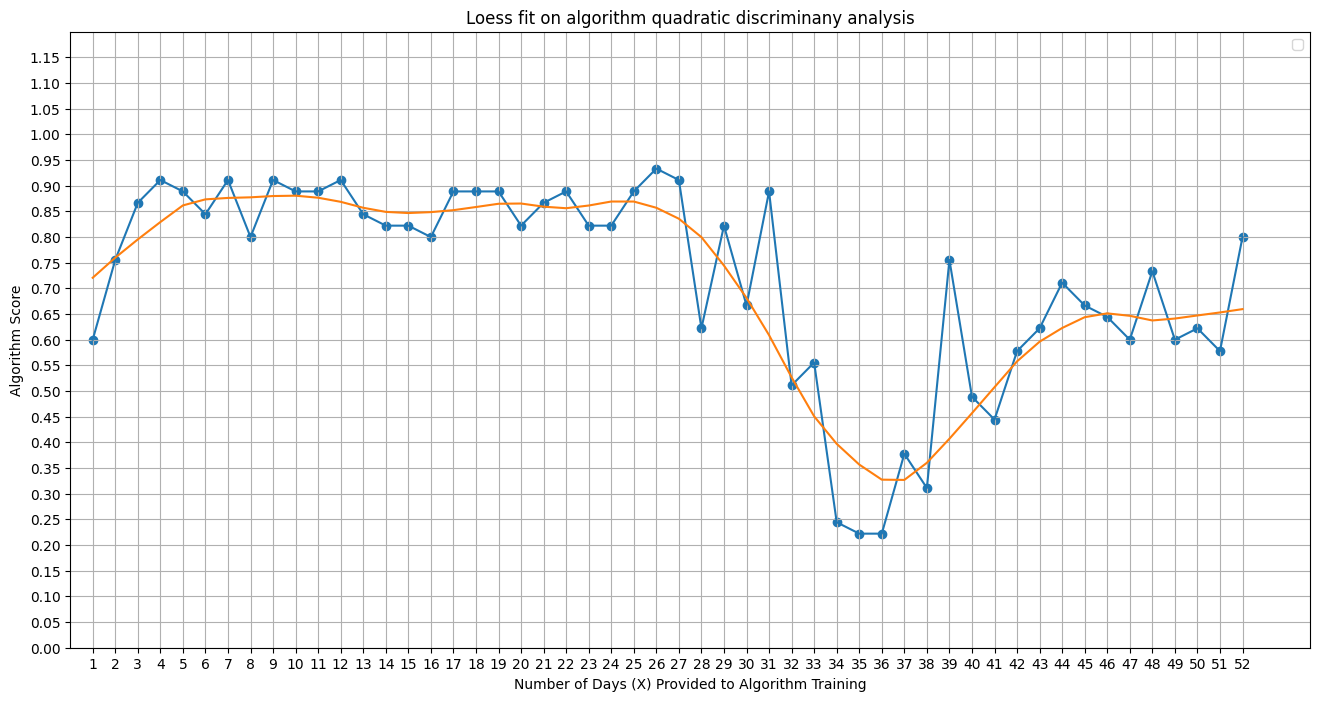

[np.float64(0.836971606250884), np.float64(0.8348229647590689), np.float64(0.8304713551561911), np.float64(0.8250240339356301), np.float64(0.8194024133333517), np.float64(0.8087555611486213), np.float64(0.7942942831675522), np.float64(0.7843392747103114), np.float64(0.7803329092077248), np.float64(0.7802738274033653), np.float64(0.7847629175771103), np.float64(0.7909848941150028), np.float64(0.7979293267246045), np.float64(0.8053457962471312), np.float64(0.8155255519936259), np.float64(0.8294816537462907), np.float64(0.8492466550044513), np.float64(0.873580521871546), np.float64(0.9011814621623739), np.float64(0.9263150198848469), np.float64(0.9480616106267723), np.float64(0.9643924817980715), np.float64(0.9741128606189469), np.float64(0.9736919323584973), np.float64(0.9637486071829643), np.float64(0.9486875705304902), np.float64(0.9307527075085839), np.float64(0.9112811343584479), np.float64(0.8943574154383579), np.float64(0.881895888164211), np.float64(0.8726365398058271), np.float64

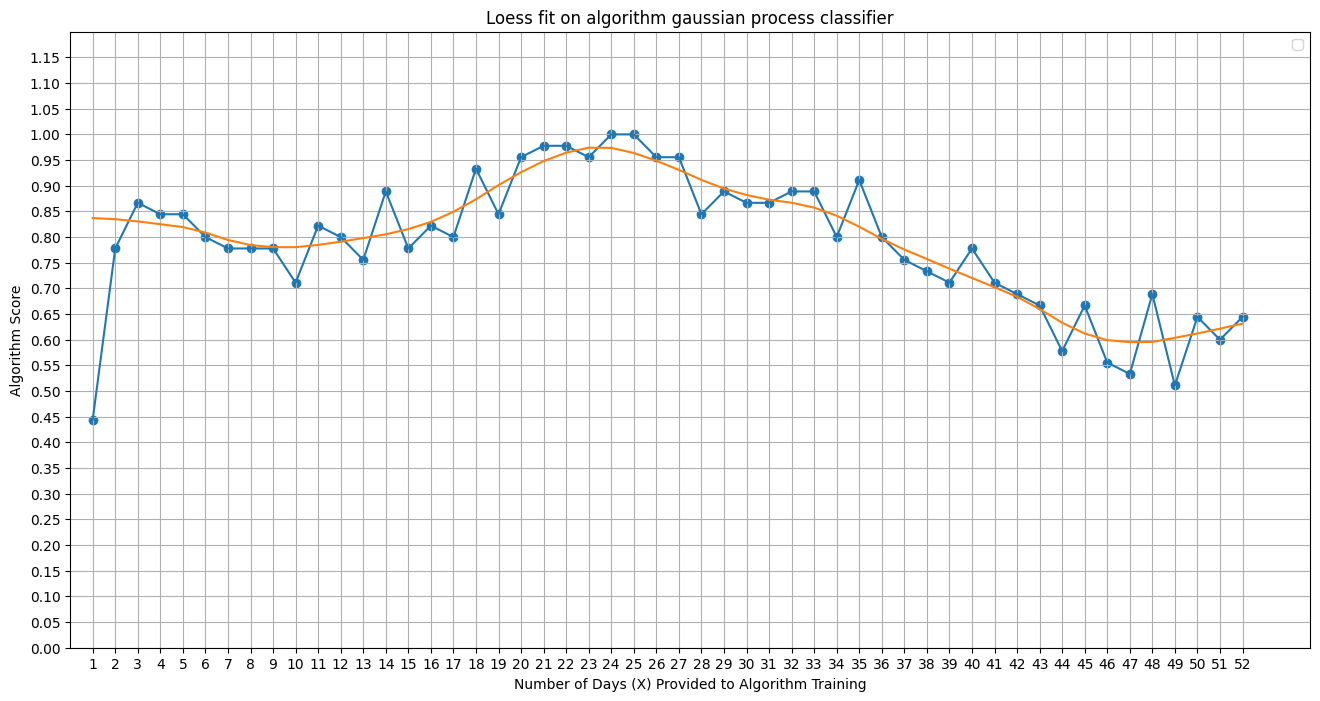

[np.float64(0.2819633674823251), np.float64(0.32398176728303546), np.float64(0.36706234278795746), np.float64(0.4112075567434642), np.float64(0.4542355922684619), np.float64(0.48728638672639074), np.float64(0.5181082798478036), np.float64(0.5522933819492746), np.float64(0.5787707812965203), np.float64(0.5890997964325572), np.float64(0.5935457999039346), np.float64(0.6000482012119941), np.float64(0.6103180402667401), np.float64(0.6209100475269177), np.float64(0.6385121829731069), np.float64(0.6637835340152799), np.float64(0.6866601731225582), np.float64(0.7071525175541984), np.float64(0.7294073460291157), np.float64(0.7464135023299319), np.float64(0.7570233119530727), np.float64(0.761989666200099), np.float64(0.7658251362897113), np.float64(0.7666818791189753), np.float64(0.760898788127399), np.float64(0.7577234086038436), np.float64(0.7630883469788556), np.float64(0.767209579656668), np.float64(0.7686092522452909), np.float64(0.7761164949611133), np.float64(0.790478183102383), np.float

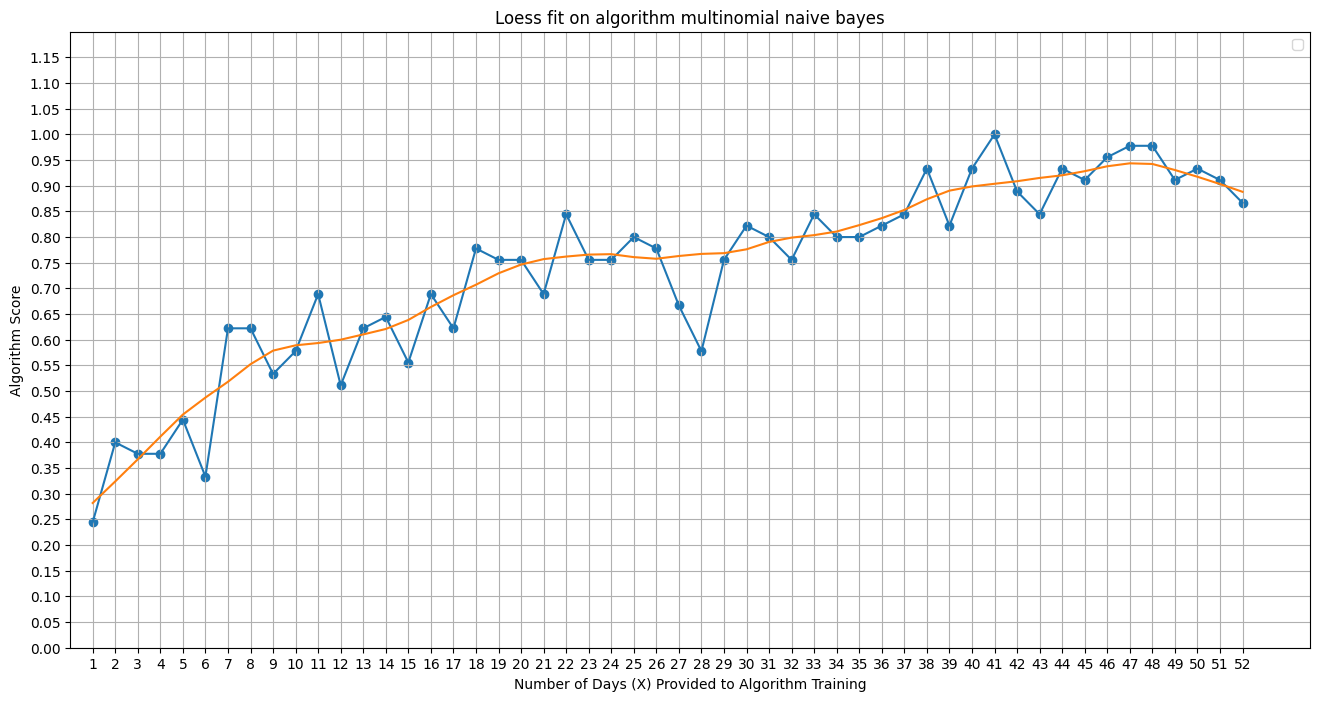

[np.float64(0.7425419391304894), np.float64(0.7616435510283857), np.float64(0.7778193578086571), np.float64(0.7922221296715365), np.float64(0.8055485259636701), np.float64(0.8109759421271889), np.float64(0.816150855056079), np.float64(0.8251702914768874), np.float64(0.8360939703856627), np.float64(0.8463995480737949), np.float64(0.859247043850841), np.float64(0.8704940216971773), np.float64(0.8773500295535492), np.float64(0.8815664057707432), np.float64(0.8869049766195475), np.float64(0.8949074179618068), np.float64(0.9048493576656974), np.float64(0.9124798345844464), np.float64(0.9207863318473459), np.float64(0.9286491207173787), np.float64(0.9354022354574206), np.float64(0.943342447655654), np.float64(0.9517650016913112), np.float64(0.957344805711188), np.float64(0.9580073637562655), np.float64(0.9552502199163668), np.float64(0.9495527891692955), np.float64(0.9432412532243181), np.float64(0.9362473323130012), np.float64(0.9316065579578111), np.float64(0.9291623640861241), np.float64(

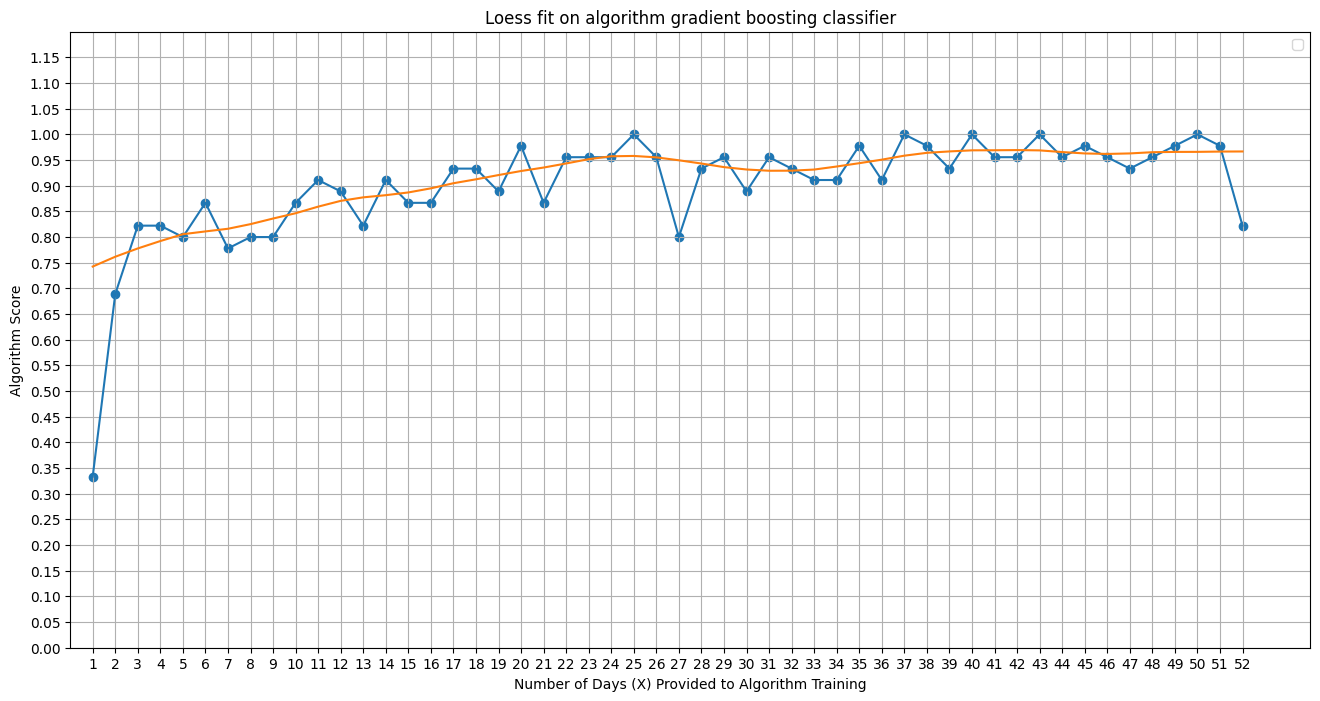

[np.float64(0.5539837473398925), np.float64(0.6029015158619805), np.float64(0.6502539884365968), np.float64(0.6971407901746407), np.float64(0.7459330796617291), np.float64(0.79034285115901), np.float64(0.8214839976634093), np.float64(0.8301041730680292), np.float64(0.8377499283037554), np.float64(0.8457164868841558), np.float64(0.850761412544914), np.float64(0.8534042014398837), np.float64(0.8560806640025392), np.float64(0.8555515294987194), np.float64(0.851025240679426), np.float64(0.8523905366618718), np.float64(0.8605920005450641), np.float64(0.872221776358408), np.float64(0.8866212099154835), np.float64(0.9047284680024297), np.float64(0.9249940360928313), np.float64(0.9420158627336557), np.float64(0.9549597700633886), np.float64(0.9634628343159679), np.float64(0.9671080424761547), np.float64(0.9709210804885912), np.float64(0.9757830231944538), np.float64(0.9799024568217127), np.float64(0.9834748381614751), np.float64(0.9874896419734394), np.float64(0.99030752539464), np.float64(0.9

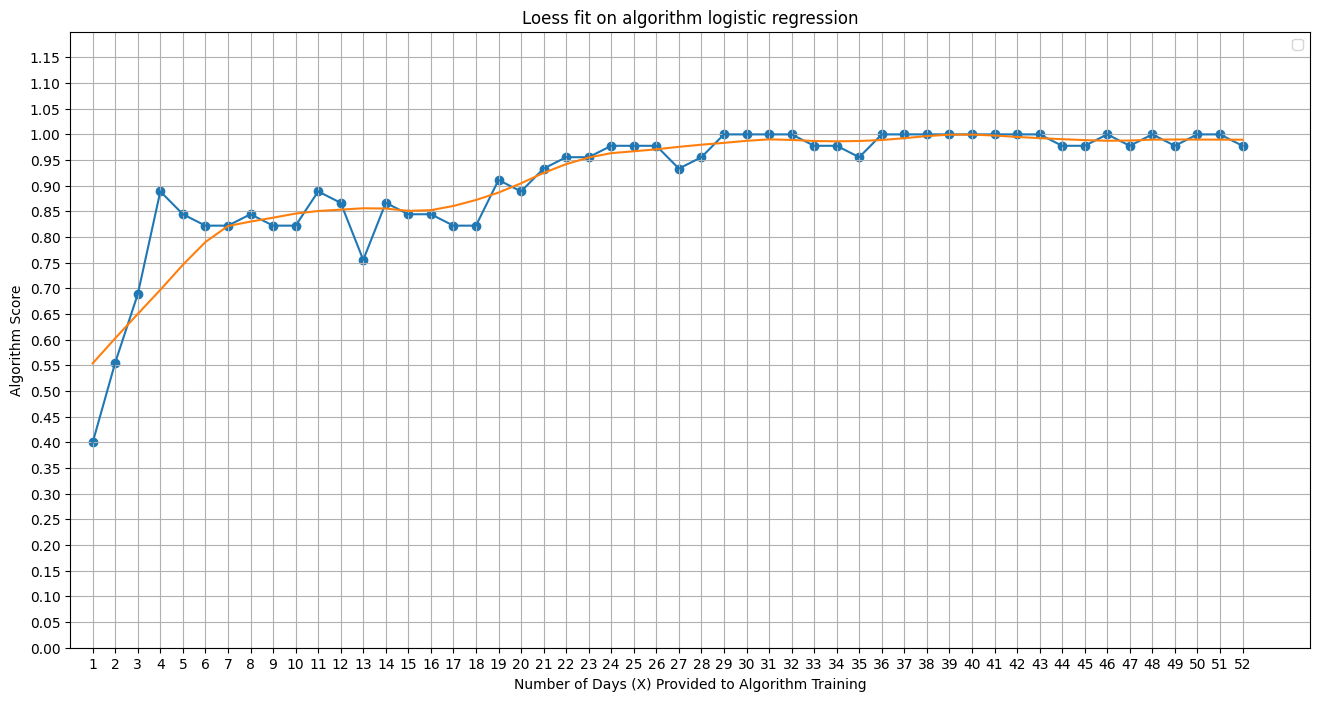

In [11]:
plot_all_loess(frac = 0.2)

In [ ]:
#Code to generate data for Figure 5 and Table 1
#Actual figure creation done in Graphpad and Word
def excel_all_loess():
    res = pd.DataFrame()
    for n in range(len(Y_vals)):
        #yarray = np.array(Y_vals[n])
        #yarray[np.isnan(yarray)] = 0
        #xout, yout, wout = loess_1d.loess_1d(np.array(X_vals), np.array(Y_vals[n]))

        lowess = sm.nonparametric.lowess
        cur = lowess(Y_vals[n], X_vals, frac=0.3)
        yout = []
        for i in range(len(cur)):
            yout.append(cur[i][1])
            
        res[f'{algosdict[n]}'] = Y_vals[n]
        res[f'{algosdict[n]} loess'] = yout
    return res

In [ ]:
all_loess = excel_all_loess()
#export to file of your choice